<a href="https://colab.research.google.com/github/hwangho-kim/Transformer_Fewshot_PdM/blob/main/Production_FDC_Pipeline_260326_Robust_R00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[System] Using device: cuda

Phase 1: Loading data, Aligning & Injecting Aging Drift...
Data ready! Pre-train: 800, Few-shot: 20, Test: 180

Phase 2: Foundation Model Pre-training (Unsupervised)...
Loading pre-trained advanced foundation model...

Phase 3: Enhancing Anomaly Detection via Few-Shot Labels...
 [Few-Shot] Training Diagnostic Head on 20 labeled samples...
   - Epoch 020/100 | Head Loss: 0.0349
   - Epoch 040/100 | Head Loss: 0.1014
   - Epoch 060/100 | Head Loss: 3.1688
   - Epoch 080/100 | Head Loss: 0.0057
   - Epoch 100/100 | Head Loss: 0.0033


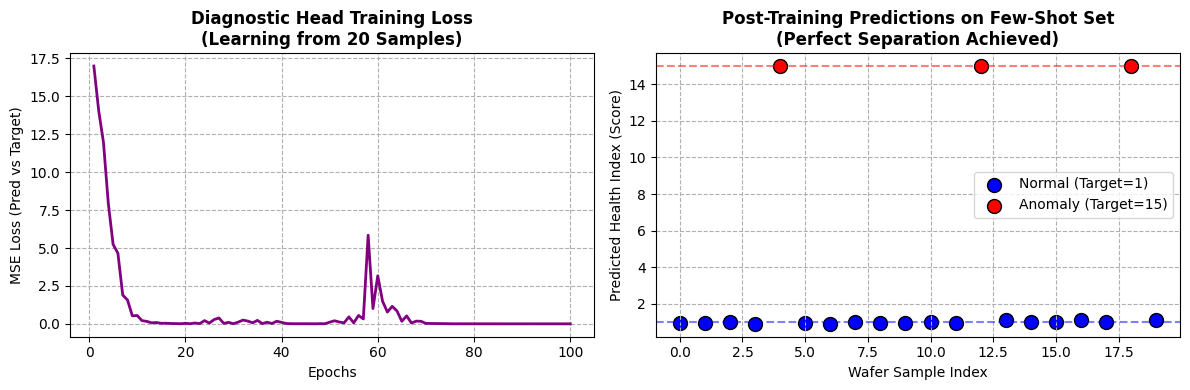


Phase 4: Plotting Anomaly Detection Control Charts...


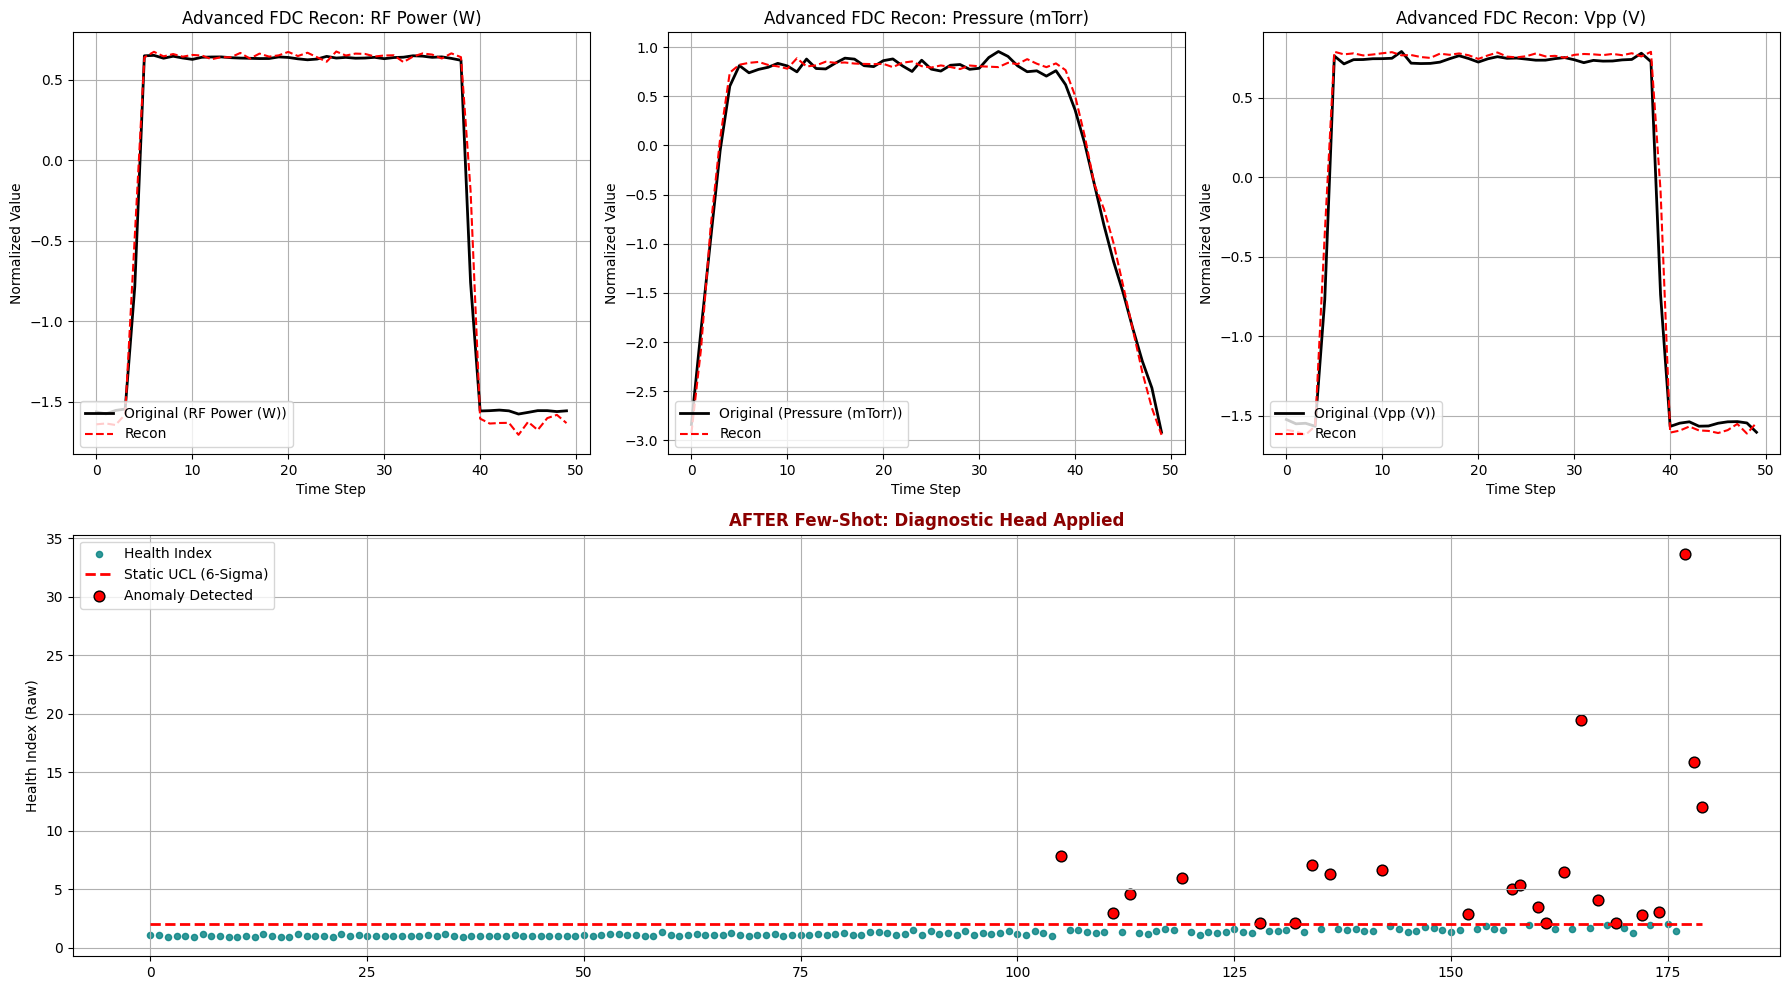


Phase 5: XAI Root Cause Analysis


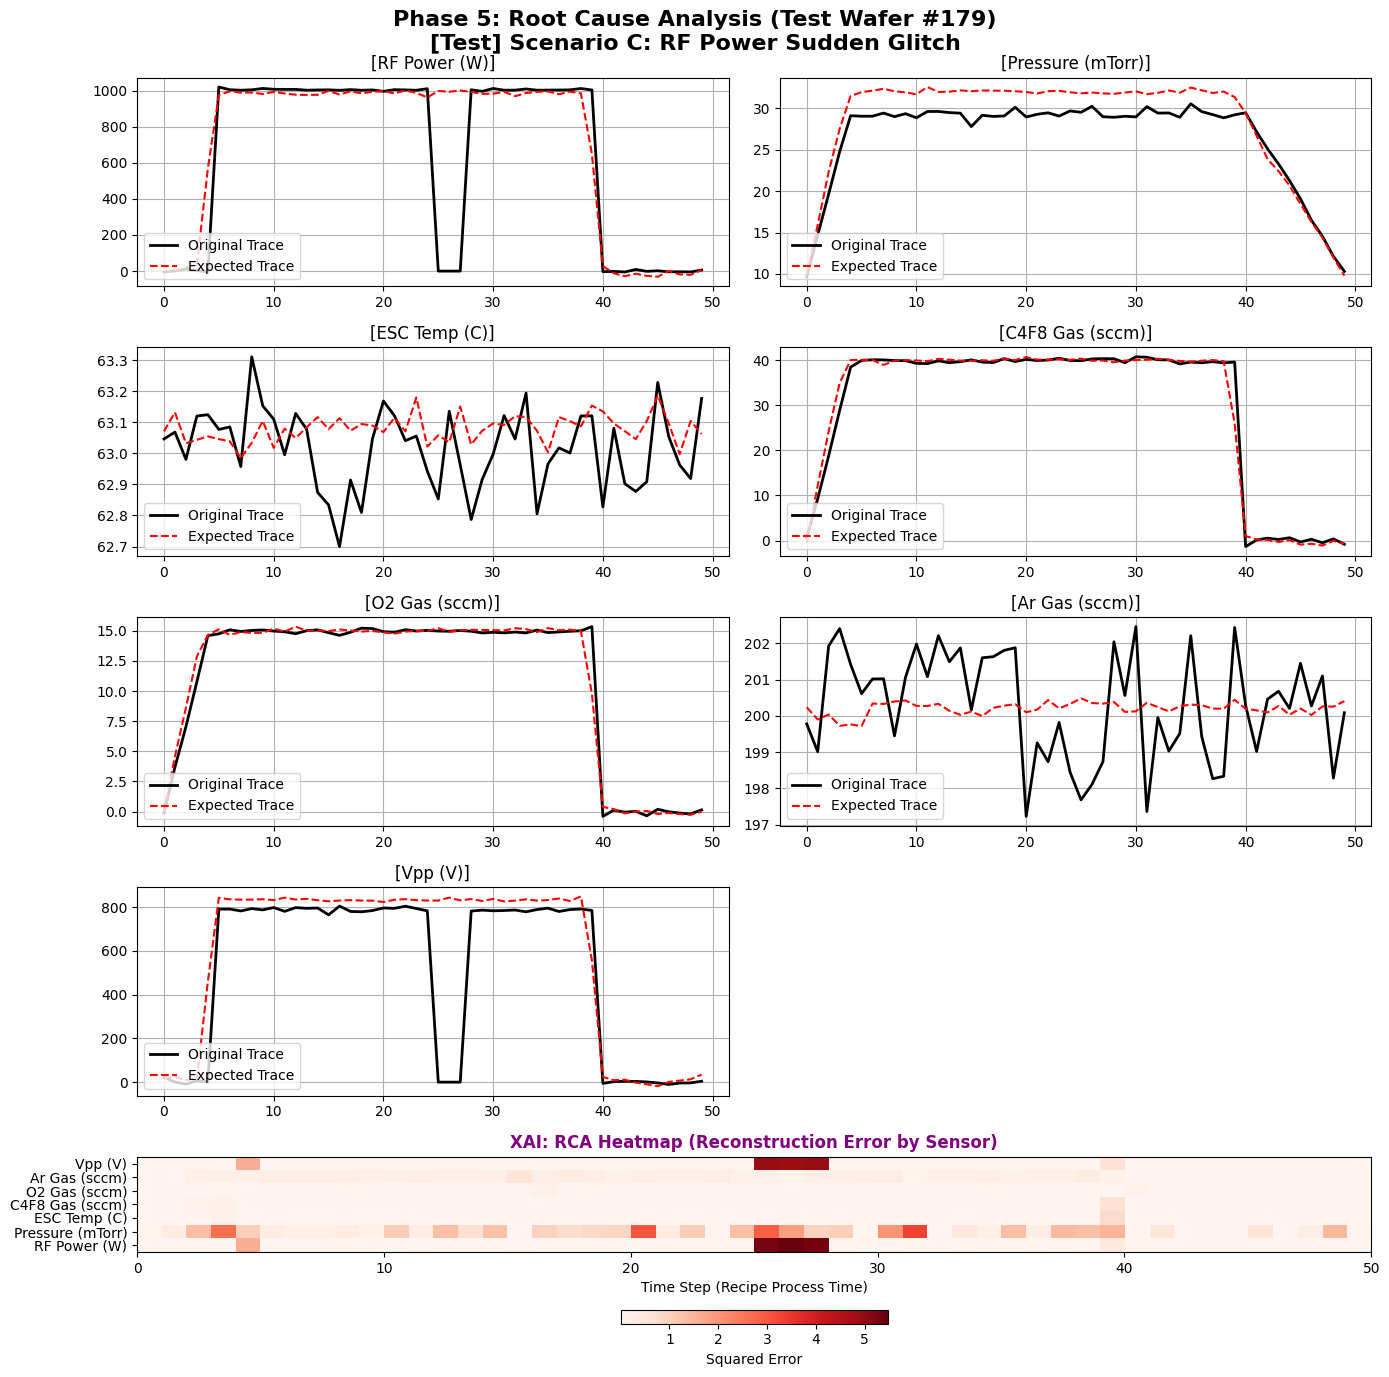


Phase 6: Equipment Health Prognostics (RUL Prediction)...


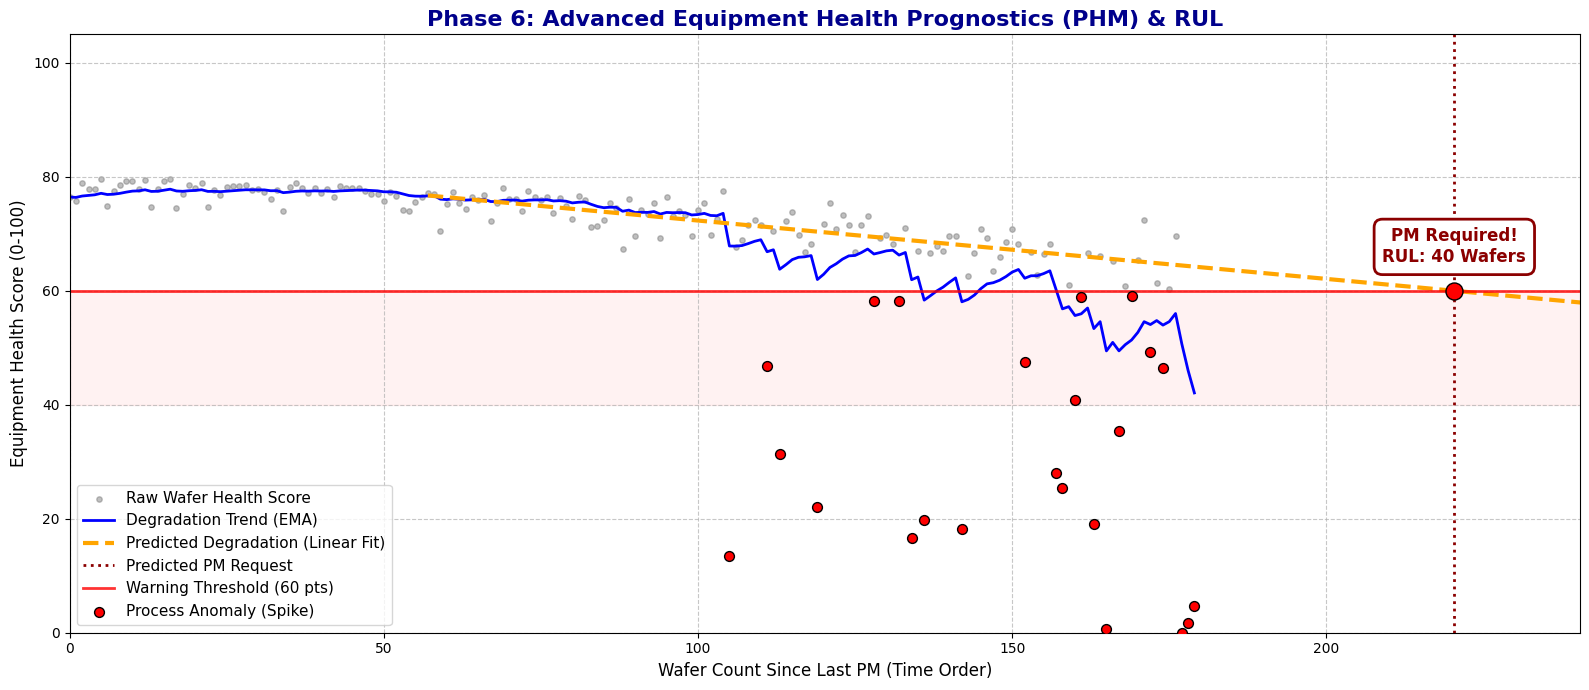


[Advanced PHM 자동 분석 리포트]
 [상태] 현재 장비 노후화 진행 속도: 웨이퍼 100장당 약 10.24점 하락 중
 [예측] 잔여 수명(RUL): 약 40장의 웨이퍼를 추가 진행한 후 장비 점수가 60점 밑으로 하락할 것으로 예상됩니다.
 [조치] 생산 계획을 참고하여 예방 정비(PM) 스케줄을 사전 수립하시기 바랍니다.



In [26]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import math
from scipy.interpolate import interp1d
import copy

# ==========================================
# 시스템 설정 및 초기화
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"[System] Using device: {device}\n")

# Few-shot learning 적용 여부 선택 ('apply', 'skip', 'both')
FEW_SHOT_OPTION = 'apply'

output_dir = "fdc_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

data_dir = "factory_data"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

trace_csv_path = os.path.join(data_dir, 'raw_fdc_trace.csv')
metro_csv_path = os.path.join(data_dir, 'raw_metrology.csv')

sensor_names = ['RF Power (W)', 'Pressure (mTorr)', 'ESC Temp (C)', 'C4F8 Gas (sccm)', 'O2 Gas (sccm)', 'Ar Gas (sccm)', 'Vpp (V)']
NUM_SENSORS = len(sensor_names)
SEQ_LENGTH = 50
FEW_SHOT_SIZE = 20

# ==========================================
# [추가] 데이터 파일이 없을 경우 임시 더미 데이터 생성 로직
# ==========================================
if not os.path.exists(trace_csv_path) or not os.path.exists(metro_csv_path):
    print("[Warning] CSV files not found. Generating dummy synthetic data for testing...")
    num_dummy_wafers = 1000
    dummy_traces, dummy_metros = [], []
    for w_id in range(num_dummy_wafers):
        step_len = np.random.randint(45, 55)
        # 정상 센서 데이터 기본 패턴 생성
        w_data = np.random.randn(step_len, NUM_SENSORS) * 0.1 + np.array([500, 20, 40, 10, 5, 100, 300])
        for step in range(step_len):
            dummy_traces.append([w_id] + w_data[step].tolist())
        dummy_metros.append([w_id, np.random.normal(150, 2)])

    pd.DataFrame(dummy_traces, columns=['Wafer_ID'] + sensor_names).to_csv(trace_csv_path, index=False)
    pd.DataFrame(dummy_metros, columns=['Wafer_ID', 'Etch_Depth_nm']).to_csv(metro_csv_path, index=False)
    print("Dummy data generated successfully.\n")

# ==========================================
# Phase 1: Data Ingestion & Degradation Simulation
# ==========================================
print("Phase 1: Loading data, Aligning & Injecting Aging Drift...")

df_trace = pd.read_csv(trace_csv_path)
df_metrology = pd.read_csv(metro_csv_path)

# 1-1. DataFrame을 웨이퍼 단위로 분할
wafer_ids = df_trace['Wafer_ID'].unique()
NUM_WAFERS = len(wafer_ids)
raw_X_list = []

grouped = df_trace.groupby('Wafer_ID')
for w_id in wafer_ids:
    wafer_data = grouped.get_group(w_id)[sensor_names].values
    raw_X_list.append(wafer_data)

y_data = df_metrology['Etch_Depth_nm'].values

scenario_mapping_en = {
    805: "[Few-Shot] Scenario A: C4F8 Gas Hunting",
    810: "[Few-Shot] Scenario B: Pressure Sluggish Ramp-up",
    815: "[Few-Shot] Scenario C: RF Power Sudden Glitch",
    NUM_WAFERS - 3: "[Test] Scenario A: C4F8 Gas Hunting",
    NUM_WAFERS - 2: "[Test] Scenario B: Pressure Sluggish Ramp-up",
    NUM_WAFERS - 1: "[Test] Scenario C: RF Power Sudden Glitch"
}

# 1-2. 1D 선형 보간(Linear Interpolation) 동기화
X_aligned = []
for w in raw_X_list:
    orig_len = len(w)
    x_orig = np.linspace(0, 1, orig_len)
    x_target = np.linspace(0, 1, SEQ_LENGTH)
    f = interp1d(x_orig, w, axis=0, kind='linear')
    X_aligned.append(f(x_target))

X_data = np.array(X_aligned)

# 1-3. 이상 시나리오 및 "장비 노후화(Aging)" 주입
r_step1 = int(SEQ_LENGTH * 0.1)
r_step2 = int(SEQ_LENGTH * 0.8)

def inject_anomalies(X, y, idx_a, idx_b, idx_c):
    # Scenario A: Hunting (C4F8)
    hunting_wave = 20 * np.sin(np.linspace(0, 15 * np.pi, r_step2 - r_step1))
    X[idx_a, r_step1:r_step2, 3] += hunting_wave
    y[idx_a] -= 25
    # Scenario B: Sluggish (Pressure)
    slow_ramp_end = int(SEQ_LENGTH * 0.6)
    sluggish_curve = np.linspace(10, 30, slow_ramp_end)
    X[idx_b, 0:slow_ramp_end, 1] = sluggish_curve + np.random.randn(slow_ramp_end) * 0.5
    y[idx_b] -= 25
    # Scenario C: Glitch (RF Power)
    glitch_idx = int(SEQ_LENGTH * 0.5)
    X[idx_c, glitch_idx:glitch_idx+3, 0] = 0
    X[idx_c, glitch_idx:glitch_idx+3, 6] = 0
    y[idx_c] -= 25

# Index out of bounds 방지 (데이터가 1000장 이상일 때만 주입)
if NUM_WAFERS >= 820:
    inject_anomalies(X_data, y_data, 805, 810, 815)
    inject_anomalies(X_data, y_data, NUM_WAFERS-3, NUM_WAFERS-2, NUM_WAFERS-1)

idx_test_start = 800 + FEW_SHOT_SIZE

# [PHM 핵심] Test 구간 장비 노후화(Degradation) 주입
aging_drift = np.linspace(0, 4.0, max(0, NUM_WAFERS - idx_test_start))
for i in range(len(aging_drift)):
    if idx_test_start + i < NUM_WAFERS:
        X_data[idx_test_start + i, :, 2] += aging_drift[i] # ESC Temp 점진적 상승

# 1-4. 데이터 스플릿
X_pretrain = X_data[:800]
X_fewshot = X_data[800:idx_test_start]
y_fewshot = y_data[800:idx_test_start]
X_test = X_data[idx_test_start:]
y_test = y_data[idx_test_start:]

is_anomaly_fewshot = (y_fewshot < 140) | (y_fewshot > 160)

# 1-5. 정규화
scaler = StandardScaler()
X_pretrain_scaled = scaler.fit_transform(X_pretrain.reshape(-1, NUM_SENSORS)).reshape(X_pretrain.shape)
if len(X_fewshot) > 0:
    X_fewshot_scaled = scaler.transform(X_fewshot.reshape(-1, NUM_SENSORS)).reshape(X_fewshot.shape)
if len(X_test) > 0:
    X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_SENSORS)).reshape(X_test.shape)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pretrain_scaled)), batch_size=64, shuffle=True)
if len(X_fewshot) > 0:
    fewshot_loader = DataLoader(TensorDataset(torch.FloatTensor(X_fewshot_scaled), torch.BoolTensor(is_anomaly_fewshot)), batch_size=4, shuffle=True)
if len(X_test) > 0:
    test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_scaled)), batch_size=32, shuffle=False)

print(f"Data ready! Pre-train: {len(X_pretrain)}, Few-shot: {len(X_fewshot)}, Test: {len(X_test)}\n")

# ==========================================
# Models Architecture (고급 아키텍처 적용)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class AdvancedFDCEncoder(nn.Module):
    def __init__(self, num_sensors=7, d_model=64, nhead=4, num_layers=2, latent_dim=16):
        super(AdvancedFDCEncoder, self).__init__()
        self.num_sensors = num_sensors
        self.d_model = d_model

        self.input_proj = nn.Linear(1, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_latent = nn.Linear(num_sensors * d_model, latent_dim)

    def forward(self, x):
        B, L, M = x.shape
        x_ci = x.transpose(1, 2).reshape(B * M, L, 1)
        x_proj = self.input_proj(x_ci)

        cls_tokens = self.cls_token.expand(B * M, -1, -1)
        x_with_cls = torch.cat((cls_tokens, x_proj), dim=1)

        x_pe = self.pos_encoder(x_with_cls)
        out = self.transformer_encoder(x_pe)

        cls_out = out[:, 0, :]
        cls_out_reshaped = cls_out.reshape(B, M * self.d_model)
        return self.fc_latent(cls_out_reshaped)

class AdvancedFDCDecoder(nn.Module):
    def __init__(self, latent_dim=16, num_sensors=7, d_model=64, nhead=4, num_layers=2, seq_len=50):
        super(AdvancedFDCDecoder, self).__init__()
        self.num_sensors = num_sensors
        self.d_model = d_model
        self.seq_len = seq_len

        self.latent_proj = nn.Linear(latent_dim, num_sensors * d_model)
        self.seq_proj = nn.Linear(d_model, d_model * seq_len)
        self.pos_encoder = PositionalEncoding(d_model)

        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, latent):
        B = latent.shape[0]
        x = self.latent_proj(latent)
        x = x.reshape(B * self.num_sensors, self.d_model)
        x = self.seq_proj(x).view(B * self.num_sensors, self.seq_len, self.d_model)

        x_pe = self.pos_encoder(x)
        out = self.transformer_decoder(x_pe)

        out_scalar = self.fc_out(out)
        recon = out_scalar.reshape(B, self.num_sensors, self.seq_len).transpose(1, 2)
        return recon

class AdvancedFDCFoundationModel(nn.Module):
    def __init__(self, num_sensors=7, d_model=64, latent_dim=16, seq_len=50):
        super(AdvancedFDCFoundationModel, self).__init__()
        self.encoder = AdvancedFDCEncoder(num_sensors, d_model=d_model, latent_dim=latent_dim)
        self.decoder = AdvancedFDCDecoder(latent_dim, num_sensors=num_sensors, d_model=d_model, seq_len=seq_len)

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        # 이전 코드와의 호환성을 위해 latent를 두 번째 인자로 반환
        return recon, latent

# ==========================================
# Phase 2: Foundation Model Training (Unsupervised)
# ==========================================
print("Phase 2: Foundation Model Pre-training (Unsupervised)...")
foundation_model = AdvancedFDCFoundationModel(num_sensors=NUM_SENSORS, seq_len=SEQ_LENGTH).to(device)
criterion_reconstruction = nn.MSELoss()
optimizer_pretrain = optim.Adam(foundation_model.parameters(), lr=0.001)

MODEL_SAVE_PATH = os.path.join(data_dir, 'foundation_model_advanced.pth')

if os.path.exists(MODEL_SAVE_PATH):
    print("Loading pre-trained advanced foundation model...")
    foundation_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
else:
    print("Training new advanced foundation model...")
    for epoch in range(30):
        foundation_model.train()
        total_loss = 0
        for (batch_x,) in train_loader:
            batch_x = batch_x.to(device)
            optimizer_pretrain.zero_grad()
            reconstruction, _ = foundation_model(batch_x)
            loss = criterion_reconstruction(reconstruction, batch_x)
            loss.backward()
            optimizer_pretrain.step()
            total_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f" Epoch {epoch+1}/30 Loss: {total_loss/len(train_loader):.4f}")
    torch.save(foundation_model.state_dict(), MODEL_SAVE_PATH)

def evaluate_anomalies(model, diag_head=None):
    model.eval()
    if diag_head is not None: diag_head.eval()

    train_errors_per_sensor = []
    with torch.no_grad():
        for (batch_x,) in train_loader:
            recon, _ = model(batch_x.to(device))
            train_errors_per_sensor.extend(torch.mean((recon.cpu() - batch_x)**2, dim=1).numpy())

    normal_sensor_mses = np.mean(train_errors_per_sensor, axis=0)

    # Train Data 기반 Health Index 계산
    train_health_indices = []
    for mse_sensor in train_errors_per_sensor:
        if diag_head is not None:
            norm_mse = torch.FloatTensor(mse_sensor / normal_sensor_mses).unsqueeze(0).to(device)
            with torch.no_grad(): h_idx = diag_head(norm_mse).item()
        else:
            h_idx = np.max(mse_sensor / normal_sensor_mses)
        train_health_indices.append(h_idx)

    # [수정] Train 단계의 Health Index 분포를 이용해 고정된(Static) 6-시그마 UCL 설정
    static_mean = np.mean(train_health_indices)
    static_std = np.std(train_health_indices)
    static_ucl = max(static_mean + 6 * static_std, 2.0)

    dynamic_ucl, test_health_indices, outliers = [], [], []
    sample_original, sample_reconstructed = None, None

    if len(X_test) == 0:
        return test_health_indices, dynamic_ucl, outliers, normal_sensor_mses, sample_original, sample_reconstructed

    with torch.no_grad():
        for i, (batch_x,) in enumerate(test_loader):
            recon, _ = model(batch_x.to(device))
            recon = recon.cpu()
            batch_mse_sensor = torch.mean((recon - batch_x)**2, dim=1).numpy()

            for idx_in_batch, mse_sensor in enumerate(batch_mse_sensor):
                if diag_head is not None:
                    norm_mse = torch.FloatTensor(mse_sensor / normal_sensor_mses).unsqueeze(0).to(device)
                    health_idx_val = diag_head(norm_mse).item()
                else:
                    health_idx_val = np.max(mse_sensor / normal_sensor_mses)

                # 동적으로 변하는 UCL 대신 고정된 스태틱 UCL 값 사용
                dynamic_ucl.append(static_ucl)

                if health_idx_val > static_ucl:
                    outliers.append(len(test_health_indices))

                test_health_indices.append(health_idx_val)

                if sample_original is None and i == 0 and idx_in_batch == 0:
                    sample_original = batch_x[0].numpy()
                    sample_reconstructed = recon[0].numpy()

    return test_health_indices, dynamic_ucl, outliers, normal_sensor_mses, sample_original, sample_reconstructed

# ==========================================
# Phase 3: Diagnostic Head 강화 (Foundation Model은 동결)
# ==========================================
print("\nPhase 3: Enhancing Anomaly Detection via Few-Shot Labels...")
class FDCDiagnosticHead(nn.Module):
    def __init__(self, num_sensors):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_sensors, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Softplus() # 항상 양수 점수 출력
        )
    def forward(self, sensor_mses):
        return self.net(sensor_mses).squeeze(-1)

diagnostic_head = FDCDiagnosticHead(NUM_SENSORS).to(device)

if FEW_SHOT_OPTION in ['skip', 'both']:
    hlth_before, ucl_before, outliers_before, norm_mses_before, orig_b, recon_b = evaluate_anomalies(foundation_model, diag_head=None)

if FEW_SHOT_OPTION in ['apply', 'both'] and len(X_fewshot) > 0:
    # 파운데이션 모델의 모든 가중치를 동결 (Freeze)
    # 즉, 데이터 복원(Reconstruction) 능력 자체는 변하지 않음!
    for param in foundation_model.parameters():
        param.requires_grad = False

    optimizer_head = optim.Adam(diagnostic_head.parameters(), lr=0.01)
    criterion_head = nn.MSELoss()
    foundation_model.eval()

    # 정상 데이터들의 센서별 평균 오차(Baseline)를 미리 계산
    temp_mses = []
    with torch.no_grad():
        for (bx,) in train_loader:
            r, _ = foundation_model(bx.to(device))
            temp_mses.extend(torch.mean((r.cpu() - bx)**2, dim=1).numpy())
    norm_mses_tensor = torch.FloatTensor(np.mean(temp_mses, axis=0)).to(device)

    print(" [Few-Shot] Training Diagnostic Head on 20 labeled samples...")
    loss_history = []

    # 100 Epoch 동안 Diagnostic Head만 학습
    for epoch in range(100):
        diagnostic_head.train()
        epoch_loss = 0
        for batch_x, batch_is_anomaly in fewshot_loader:
            batch_x, batch_is_anomaly = batch_x.to(device), batch_is_anomaly.to(device)
            optimizer_head.zero_grad()

            with torch.no_grad():
                # 파운데이션 모델은 단지 복원 오차(MSE)를 제공하는 특징 추출기 역할만 수행
                recon, _ = foundation_model(batch_x)
                mse_per_sensor = torch.mean((recon - batch_x)**2, dim=1)
                normalized_mse = mse_per_sensor / norm_mses_tensor

            # 불량이면 15점, 정상이면 1점이라는 타겟 부여
            target_score = torch.where(batch_is_anomaly, torch.tensor(15.0).to(device), torch.tensor(1.0).to(device))

            # Diagnostic Head는 이 원시 MSE를 해석하여 점수를 예측
            pred_score = diagnostic_head(normalized_mse)
            loss = criterion_head(pred_score, target_score)

            loss.backward()
            optimizer_head.step()
            epoch_loss += loss.item()

        loss_history.append(epoch_loss / len(fewshot_loader))
        if (epoch+1) % 20 == 0:
            print(f"   - Epoch {epoch+1:03d}/100 | Head Loss: {loss_history[-1]:.4f}")

    # --- [추가] Phase 3 중간 결과 시각화 ---
    fig_head = plt.figure(figsize=(12, 4))

    # 1. 학습 로스 추이 곡선
    ax_loss = fig_head.add_subplot(1, 2, 1)
    ax_loss.plot(range(1, 101), loss_history, color='purple', linewidth=2)
    ax_loss.set_title('Diagnostic Head Training Loss\n(Learning from 20 Samples)', fontweight='bold')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('MSE Loss (Pred vs Target)')
    ax_loss.grid(True, linestyle='--')

    # 2. 학습 완료 후 Few-Shot 데이터 예측 점수 분포 확인
    diagnostic_head.eval()
    pred_scores_plot = []
    true_labels_plot = []
    with torch.no_grad():
        for batch_x, batch_is_anomaly in fewshot_loader:
            recon, _ = foundation_model(batch_x.to(device))
            mse_per_sensor = torch.mean((recon - batch_x.to(device))**2, dim=1)
            normalized_mse = mse_per_sensor / norm_mses_tensor
            preds = diagnostic_head(normalized_mse).cpu().numpy()
            pred_scores_plot.extend(preds)
            true_labels_plot.extend(batch_is_anomaly.numpy())

    ax_scatter = fig_head.add_subplot(1, 2, 2)
    colors = ['blue' if not l else 'red' for l in true_labels_plot]
    labels = ['Normal (Target=1)' if not l else 'Anomaly (Target=15)' for l in true_labels_plot]

    for i in range(len(pred_scores_plot)):
        # 중복 범례 방지
        lbl = labels[i] if labels[i] not in ax_scatter.get_legend_handles_labels()[1] else ""
        ax_scatter.scatter(i, pred_scores_plot[i], color=colors[i], s=100, edgecolors='black', label=lbl)

    ax_scatter.axhline(y=1, color='blue', linestyle='--', alpha=0.5)
    ax_scatter.axhline(y=15, color='red', linestyle='--', alpha=0.5)
    ax_scatter.set_title('Post-Training Predictions on Few-Shot Set\n(Perfect Separation Achieved)', fontweight='bold')
    ax_scatter.set_xlabel('Wafer Sample Index')
    ax_scatter.set_ylabel('Predicted Health Index (Score)')
    ax_scatter.legend()
    ax_scatter.grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()
    # -----------------------------------

    hlth_after, ucl_after, outliers_after, norm_mses_after, orig_a, recon_a = evaluate_anomalies(foundation_model, diag_head=diagnostic_head)

final_outliers = outliers_after if FEW_SHOT_OPTION in ['apply', 'both'] else outliers_before
final_health = hlth_after if FEW_SHOT_OPTION in ['apply', 'both'] else hlth_before
final_ucl = ucl_after if FEW_SHOT_OPTION in ['apply', 'both'] else ucl_before
sample_original = orig_a if FEW_SHOT_OPTION in ['apply', 'both'] else orig_b
sample_reconstructed = recon_a if FEW_SHOT_OPTION in ['apply', 'both'] else recon_b
normal_sensor_mses = norm_mses_after if FEW_SHOT_OPTION in ['apply', 'both'] else norm_mses_before

# [수정] 100점 만점 Health Score 변환 (지수 감쇠 함수 사용)
final_health_arr = np.array(final_health)
final_ucl_arr = np.array(final_ucl)

# Health Index가 동적 UCL과 동일할 때(ratio=1) 약 60점이 되도록 변환 (100 * exp(-0.5108) ≈ 60)
# 극단적인 이상치(Spike)가 발생해도 점수가 바닥에 잘리지 않고 곡선을 따라 스케일이 보존됨
ratio = final_health_arr / final_ucl_arr
final_scores_100 = 100 * np.exp(-0.5108 * ratio)
final_scores_100 = np.clip(final_scores_100, 0, 100)

# ==========================================
# Phase 4: Final Visualization (Control Charts)
# ==========================================
if len(X_test) > 0:
    print("\nPhase 4: Plotting Anomaly Detection Control Charts...")

    # FEW_SHOT_OPTION이 'apply'인 경우 2줄짜리 플롯으로 조정
    fig_rows = 3 if FEW_SHOT_OPTION == 'both' else 2
    fig = plt.figure(figsize=(18, 5 * fig_rows))
    gs = gridspec.GridSpec(fig_rows, 3, figure=fig)

    rep_sensor_indices = [0, 1, 6]
    for plot_idx, sensor_idx in enumerate(rep_sensor_indices):
        ax = fig.add_subplot(gs[0, plot_idx])
        ax.plot(sample_original[:, sensor_idx], label=f'Original ({sensor_names[sensor_idx]})', color='black', linewidth=2)
        ax.plot(sample_reconstructed[:, sensor_idx], label='Recon', color='red', linestyle='--')
        ax.set_title(f'Advanced FDC Recon: {sensor_names[sensor_idx]}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Normalized Value')
        ax.legend(loc='lower left')
        ax.grid(True)

    if FEW_SHOT_OPTION == 'both':
        ax_before = fig.add_subplot(gs[1, :])
        ax_before.scatter(range(len(hlth_before)), hlth_before, color='gray', s=20, alpha=0.7, label='Health Index')
        ax_before.plot(range(len(ucl_before)), ucl_before, color='red', linestyle='--', linewidth=2, label='Static UCL (6-Sigma)')
        if len(outliers_before) > 0:
            ax_before.scatter(outliers_before, np.array(hlth_before)[outliers_before], color='orange', s=60, edgecolors='black', label='Anomaly Detected')
        ax_before.set_title('BEFORE Few-Shot: Baseline Autoencoder (Max Error Ratio)', fontweight='bold')
        ax_before.set_ylabel('Health Index (Raw)')
        ax_before.legend(loc='upper left')
        ax_before.grid(True)

    # apply 거나 both 일 때 출력 (마지막 줄)
    last_row_idx = 2 if FEW_SHOT_OPTION == 'both' else 1
    ax_final = fig.add_subplot(gs[last_row_idx, :])

    plot_hlth = hlth_after if FEW_SHOT_OPTION in ['apply', 'both'] else hlth_before
    plot_ucl = ucl_after if FEW_SHOT_OPTION in ['apply', 'both'] else ucl_before
    plot_outliers = outliers_after if FEW_SHOT_OPTION in ['apply', 'both'] else outliers_before

    color_hlth = 'teal' if FEW_SHOT_OPTION in ['apply', 'both'] else 'gray'
    title_text = 'AFTER Few-Shot: Diagnostic Head Applied' if FEW_SHOT_OPTION in ['apply', 'both'] else 'BEFORE Few-Shot: Baseline Autoencoder'

    ax_final.scatter(range(len(plot_hlth)), plot_hlth, color=color_hlth, s=20, alpha=0.8, label='Health Index')
    ax_final.plot(range(len(plot_ucl)), plot_ucl, color='red', linestyle='--', linewidth=2, label='Static UCL (6-Sigma)')
    if len(plot_outliers) > 0:
        ax_final.scatter(plot_outliers, np.array(plot_hlth)[plot_outliers], color='red', s=60, edgecolors='black', label='Anomaly Detected')

    ax_final.set_title(title_text, fontweight='bold', color='darkred' if FEW_SHOT_OPTION in ['apply', 'both'] else 'black')
    ax_final.set_ylabel('Health Index (Raw)')
    ax_final.legend(loc='upper left')
    ax_final.grid(True)

    plt.tight_layout()
    plt.show()

# ==========================================
# Phase 5: XAI & Root Cause Analysis
# ==========================================
print("\nPhase 5: XAI Root Cause Analysis")
if len(final_outliers) > 0 and len(X_test) > 0:
    # 가장 마지막 불량 1개만 XAI 수행
    for anomaly_idx in [final_outliers[-1]]:
        original_wafer_id = idx_test_start + anomaly_idx
        scenario_desc_en = scenario_mapping_en.get(original_wafer_id, "Unknown General Drift")

        anomaly_tensor = torch.FloatTensor(X_test_scaled[anomaly_idx]).unsqueeze(0)
        foundation_model.eval()

        with torch.no_grad():
            anomaly_recon, _ = foundation_model(anomaly_tensor.to(device))
            anomaly_recon = anomaly_recon.cpu()

        anomaly_original_np = anomaly_tensor.squeeze(0).numpy()
        anomaly_recon_np = anomaly_recon.squeeze(0).numpy()

        raw_anomaly_original_np = scaler.inverse_transform(anomaly_original_np)
        raw_anomaly_recon_np = scaler.inverse_transform(anomaly_recon_np)

        fig = plt.figure(figsize=(14, 14))
        fig.suptitle(f'Phase 5: Root Cause Analysis (Test Wafer #{anomaly_idx})\n{scenario_desc_en}', fontsize=16, fontweight='bold')
        gs = gridspec.GridSpec(5, 2, figure=fig, height_ratios=[1, 1, 1, 1, 0.8])

        axs = []
        for i in range(4):
            for j in range(2):
                if i * 2 + j < NUM_SENSORS: axs.append(fig.add_subplot(gs[i, j]))

        for i in range(NUM_SENSORS):
            axs[i].plot(raw_anomaly_original_np[:, i], label='Original Trace', color='black', linewidth=2)
            axs[i].plot(raw_anomaly_recon_np[:, i], label='Expected Trace', color='red', linestyle='--')
            axs[i].set_title(f'[{sensor_names[i]}]', color='black')
            axs[i].legend(loc='lower left')
            axs[i].grid(True)

        ax_attn = fig.add_subplot(gs[4, :])
        rca_error_matrix = ((anomaly_original_np - anomaly_recon_np)**2).T
        im = ax_attn.imshow(rca_error_matrix, cmap='Reds', aspect='auto', extent=[0, SEQ_LENGTH, NUM_SENSORS, 0])
        ax_attn.set_title('XAI: RCA Heatmap (Reconstruction Error by Sensor)', fontweight='bold', color='purple')
        ax_attn.set_xlabel('Time Step (Recipe Process Time)')
        ax_attn.set_yticks(np.arange(NUM_SENSORS) + 0.5)
        ax_attn.set_yticklabels(sensor_names[::-1]) # Y축 레이블 역순 정렬 보정
        fig.colorbar(im, ax=ax_attn, orientation='horizontal', fraction=0.08, pad=0.35, label='Squared Error')
        plt.tight_layout()
        plt.show()

# ==========================================
# Phase 6: PHM 장비 노후화 추적 및 RUL 예측 대시보드
# ==========================================
if len(X_test) > 0:
    print("\nPhase 6: Equipment Health Prognostics (RUL Prediction)...")

    normal_idx = [i for i in range(len(final_scores_100)) if i not in final_outliers]
    normal_scores = final_scores_100[normal_idx]

    df_scores = pd.DataFrame({'score': final_scores_100})
    ema_scores = df_scores['score'].ewm(span=20, adjust=False).mean().values

    recent_n = min(100, len(normal_idx))
    fit_x = normal_idx[-recent_n:]
    fit_y = normal_scores[-recent_n:]

    z = np.polyfit(fit_x, fit_y, 1)
    p = np.poly1d(z)
    slope, intercept = z[0], z[1]

    rul_wafers = -1
    predicted_fail_idx = -1

    if slope < 0:
        predicted_fail_idx = (60 - intercept) / slope
        rul_wafers = int(predicted_fail_idx - len(final_scores_100))
        if rul_wafers < 0: rul_wafers = 0

    fig_phm = plt.figure(figsize=(16, 7))
    ax_phm = fig_phm.add_subplot(111)

    # [수정] Raw Wafer Health Score를 선형 플롯에서 Scatter 형태로 변경
    ax_phm.scatter(range(len(final_scores_100)), final_scores_100, color='gray', s=15, alpha=0.5, label='Raw Wafer Health Score')
    ax_phm.plot(range(len(ema_scores)), ema_scores, color='blue', linewidth=2, label='Degradation Trend (EMA)')

    if slope < 0 and 0 < rul_wafers < 1000:
        future_x = np.arange(fit_x[0], int(predicted_fail_idx) + 50)
        future_y = p(future_x)
        ax_phm.plot(future_x, future_y, color='orange', linestyle='--', linewidth=3, label=f'Predicted Degradation (Linear Fit)')

        ax_phm.axvline(x=predicted_fail_idx, color='darkred', linestyle=':', linewidth=2, label=f'Predicted PM Request')
        ax_phm.scatter([predicted_fail_idx], [60], color='red', s=150, zorder=5, edgecolors='black')

        bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec="darkred", lw=2)
        ax_phm.text(predicted_fail_idx, 65, f'PM Required!\nRUL: {rul_wafers} Wafers',
                    color='darkred', fontweight='bold', ha='center', fontsize=12, bbox=bbox_props)

    ax_phm.axhline(y=60, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Warning Threshold (60 pts)')
    ax_phm.fill_between(range(len(final_scores_100) + 100), 40, 60, color='red', alpha=0.05)

    if len(final_outliers) > 0:
        ax_phm.scatter(final_outliers, final_scores_100[final_outliers], color='red', s=50, edgecolors='black', label='Process Anomaly (Spike)', zorder=4)

    ax_phm.set_title('Phase 6: Advanced Equipment Health Prognostics (PHM) & RUL', fontsize=16, fontweight='bold', color='darkblue')
    ax_phm.set_xlabel('Wafer Count Since Last PM (Time Order)', fontsize=12)
    ax_phm.set_ylabel('Equipment Health Score (0-100)', fontsize=12)
    ax_phm.set_ylim(0, 105) # 스케일 하한을 0으로 조정하여 Spike를 잘 보여줌
    ax_phm.set_xlim(0, max(len(final_scores_100) + 20, predicted_fail_idx + 20 if predicted_fail_idx > 0 else 0))
    ax_phm.legend(loc='lower left', fontsize=11)
    ax_phm.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*70)
    print(f"[Advanced PHM 자동 분석 리포트]")
    print("="*70)
    if slope < 0:
        print(f" [상태] 현재 장비 노후화 진행 속도: 웨이퍼 100장당 약 {abs(slope)*100:.2f}점 하락 중")
        if rul_wafers > 0:
            print(f" [예측] 잔여 수명(RUL): 약 {rul_wafers}장의 웨이퍼를 추가 진행한 후 장비 점수가 60점 밑으로 하락할 것으로 예상됩니다.")
            print(" [조치] 생산 계획을 참고하여 예방 정비(PM) 스케줄을 사전 수립하시기 바랍니다.")
        else:
            print(" [경고] 이미 장비 점수가 경고 임계점(60점)을 초과 하락했습니다. 즉각적인 PM 조치가 필요합니다.")
    else:
        print(" [정상] 현재 뚜렷한 장비 노후화 추세(Degradation Trend)가 관찰되지 않고 안정적인 상태입니다.")
    print("="*70 + "\n")